## ⚙️ Import Libraries

# Custom UNet using Self-Attention and Pyramidal Pooling with Adaptative Combined Loss (Dice + Focal)

## Homework 2 - FORmidable
---

In [1]:
# All the comments in this notebook corresponds to new parts, please refer to our baseline notebook for more details.
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras as tfk
from keras import layers as tfkl
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
print(f"GPU devices: {len(tf.config.list_physical_devices('GPU'))}")

from keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tfk.__version__}")

on_kaggle = True

GPU devices: 1
TensorFlow version: 2.16.1
Keras version: 3.3.3


## ⏳ Load and Visualize the Data

In [2]:
if (on_kaggle):
    %cd "/kaggle/input"
    data = np.load("mars-dataset/mars_for_students.npz")
else: 
    data = np.load("mars_for_students.npz")

training_set = data["training_set"]

X_train_original = training_set[:, 0]
y_train_original = training_set[:, 1]
X_test_original = data["test_set"]

print(f"Training X shape: {X_train_original.shape}")
print(f"Training y shape: {y_train_original.shape}")
print(f"Test X shape: {X_test_original.shape}")

/kaggle/input
Training X shape: (2615, 64, 128)
Training y shape: (2615, 64, 128)
Test X shape: (10022, 64, 128)


In [3]:
colors = ['black', 'saddlebrown', 'gray', 'khaki', 'blue']
label_names = ['background', 'soil', 'bedrock', 'sand', 'big rock']

cmap = plt.cm.colors.ListedColormap(colors)

def plot_image_label(images, labels, num_rows, num_cols, range_max):
    _, axes = plt.subplots(num_rows, 2 * num_cols, figsize=(4*num_cols, num_rows))
    
    for i in range(num_rows):
        for j in range(num_cols):
            idx = i * num_cols + j
            axes[i, j * 2].imshow(images[idx], cmap='gray', vmin=0, vmax=range_max)
            axes[i, j * 2].axis('off')
            axes[i, j * 2 + 1].imshow(labels[idx], cmap=cmap, vmin=0, vmax=4)
            axes[i, j * 2 + 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
#plot_image_label(X_train_original, y_train_original, 6, 3, 255)

In [5]:
def get_indices_to_remove(y_train, label_to_remove):
    y_reshaped = y_train.reshape(y_train.shape[0], -1)
    label_flat = label_to_remove.reshape(1, -1)
    indices_to_remove = np.where(np.all(y_reshaped == label_flat, axis=1))[0]
    return indices_to_remove

def remove_indices(X_train, y_train, indices_to_remove):
    mask = np.ones(X_train.shape[0], dtype=bool)
    mask[indices_to_remove] = False
    X_train_new = X_train[mask]
    y_train_new = y_train[mask]
    return X_train_new, y_train_new

label_to_remove = y_train_original[2561]

indices_to_remove = get_indices_to_remove(y_train_original, label_to_remove)
X_train_cleaned, y_train_cleaned = remove_indices(X_train_original, y_train_original, indices_to_remove)
print(f"Original train shape: {X_train_original.shape}, New shape: {X_train_cleaned.shape}")

X_train_original = X_train_cleaned
y_train_original = y_train_cleaned

Original train shape: (2615, 64, 128), New shape: (2505, 64, 128)


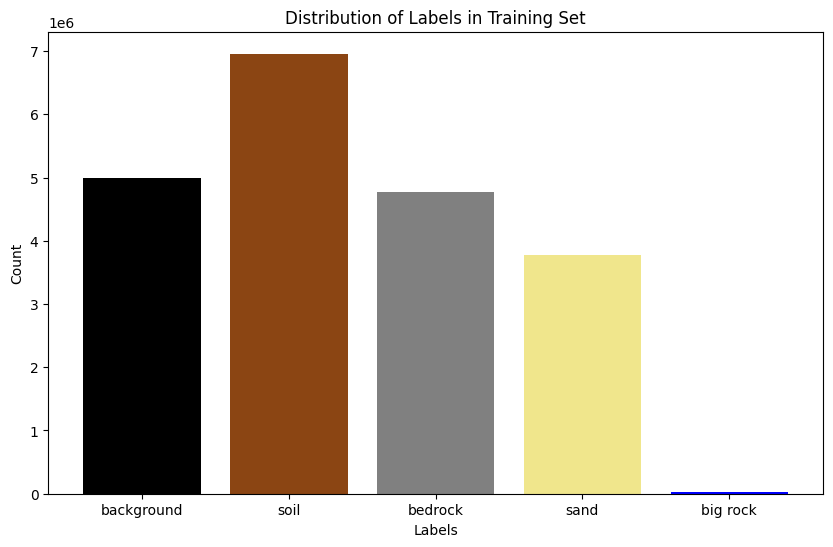

In [6]:
# Count the occurrences of each label
label_counts = np.bincount(y_train_original.flatten().astype(int), minlength=len(labels))

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.bar(labels, label_counts, color=colors)
plt.xlabel('Labels')
plt.ylabel('Count')
#plt.yscale('log')
plt.title('Distribution of Labels in Training Set')
plt.show()

## Prepare the dataset

In [7]:
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
PATIENCE = 30
EPOCHS = 1000
SPLITS_SIZE = 300
SEED = 42

In [8]:
def apply_preprocessing(images):
    images = images[..., tf.newaxis] / 255.0
    ret = []
    for image in images:
        mean_brightness = tf.reduce_mean(image)
        delta = 1.0 * (0.5 - mean_brightness)
        image = tf.image.adjust_brightness(image, delta=delta)
        image = tf.image.adjust_contrast(image, contrast_factor=3.0)
        image = tf.clip_by_value(image, 0.0, 1.0) 
        ret.append(image)
    return np.array(ret)

X_train = apply_preprocessing(X_train_original)
y_train = y_train_original[..., tf.newaxis]

X_train = tf.cast(X_train, tf.float32)
y_train = tf.cast(y_train, tf.int32)

In [9]:
train_img, val_img, train_lbl, val_lbl = train_test_split(X_train.numpy().squeeze(), y_train.numpy().squeeze(), test_size=SPLITS_SIZE)
print("Data splitted!")
print(f"\nNumber of images:")
print(f"Train: {len(train_img)}")
print(f"Validation: {len(val_img)}")

train_img = train_img[..., tf.newaxis]
val_img = val_img[..., tf.newaxis]
train_lbl = train_lbl[..., tf.newaxis]
val_lbl = val_lbl[..., tf.newaxis]

Data splitted!

Number of images:
Train: 2205
Validation: 300


In [10]:
def augment_images(image, label, n_aug_0123, n_aug_4, seed=SEED):
    n_augmentations = tf.cond(
        tf.reduce_any(tf.equal(label, 4)),
        lambda: tf.constant(n_aug_4), 
        lambda: tf.constant(n_aug_0123)      
    )

    augmented_images = tf.TensorArray(dtype=tf.float32, size=n_augmentations+1)
    augmented_labels = tf.TensorArray(dtype=tf.float32, size=n_augmentations+1)
    augmented_images = augmented_images.write(0, image)
    augmented_labels = augmented_labels.write(0, label)

    for i in tf.range(1, n_augmentations+1):
        augmented_image, augmented_label = image, label

        if tf.random.uniform(()) > 0.2:
            augmented_image = tf.image.flip_left_right(augmented_image)
            augmented_label = tf.image.flip_left_right(augmented_label)

        if tf.random.uniform(()) > 0.2:
            augmented_image = tf.image.flip_up_down(augmented_image)
            augmented_label = tf.image.flip_up_down(augmented_label)

        if tf.random.uniform(()) > 0.2:
            noise = tf.random.normal(shape=tf.shape(augmented_image), mean=0.0, stddev=0.008)
            augmented_image = tf.clip_by_value(augmented_image + noise, 0.0, 1.0)

        if tf.random.uniform(()) > 0.2:
            zoom_factor = tf.random.uniform([], minval=1, maxval=1.2, dtype=tf.float32, seed=seed)
            central_fraction = 1.0 / zoom_factor
            zoom_image = tf.image.central_crop(augmented_image, central_fraction)
            zoom_label = tf.image.central_crop(augmented_label, central_fraction)
            augmented_image = tf.image.resize(zoom_image, tf.shape(image)[0:2])
            augmented_label = tf.image.resize(zoom_label, tf.shape(label)[0:2])

        augmented_images = augmented_images.write(i, augmented_image)
        augmented_labels = augmented_labels.write(i, augmented_label)

    return augmented_images.stack(), augmented_labels.stack()

In [12]:
def make_dataset(images, labels, batch_size, shuffle, augment=False, n_aug0123=1, n_aug_4=20, seed=SEED):
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.map(lambda image, label: (image, tf.cast(label, tf.float32)), num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def augmentation_map(image, label):
            augmented_images, augmented_labels = augment_images(image, label, n_aug0123, n_aug_4, seed=seed)
            return tf.data.Dataset.from_tensor_slices((augmented_images, augmented_labels))
        dataset = dataset.flat_map(augmentation_map)
    
    dataset = dataset.map(lambda image, label: (image, tf.cast(label, tf.int32)), num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=batch_size * 2, seed=seed)

    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = make_dataset(train_img, train_lbl, batch_size=BATCH_SIZE, shuffle=True, augment=True, n_aug0123=1, n_aug_4=2)
val_dataset = make_dataset(val_img, val_lbl, batch_size=BATCH_SIZE, shuffle=False)
print("Datasets created!")

for images, labels in train_dataset.take(1):
    input_shape = images.shape[1:]
    print(f"Input shape: {input_shape}")
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    break

total_images = 0
for images, labels in train_dataset:
    total_images += images.shape[0]

print(f"Total number of images in train_dataset: {total_images}")

Datasets created!
Input shape: (64, 128, 1)
Images shape: (64, 64, 128, 1)
Labels shape: (64, 64, 128, 1)
Total number of images in train_dataset: 4470


## 🛠️ Train and Save the Model

### This Model is a tentative of implementation of the suggestions made in the April 2024 paper from Junbo Li, Keyan Chen, Gengju Tian, Lu Li and Zhenwei Shi : https://arxiv.org/html/2404.04155v1

### The main ideas are  : Using self-attention to link different part of the image during the training and capture potential distant dependencies, and using Pyramid poonling to detect features at various scales in the image.

In [13]:
from tensorflow.keras import layers, Model

def conv_block(x, filters):
    """Convolutional block with BatchNormalization and ReLU."""
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    return x

def encoder_block(x, filters):
    """Encoder block with MaxPooling."""
    x = conv_block(x, filters)
    skip = x
    x = layers.MaxPooling2D((2, 2))(x)
    return x, skip

def mini_aspp(x, filters):
    """Lightweight Atrous Spatial Pyramid Pooling."""
    atrous1 = layers.Conv2D(filters, 3, padding="same", dilation_rate=1, activation="relu")(x)
    atrous2 = layers.Conv2D(filters, 3, padding="same", dilation_rate=3, activation="relu")(x)
    atrous3 = layers.Conv2D(filters, 3, padding="same", dilation_rate=5, activation="relu")(x)
    concat = layers.Concatenate()([atrous1, atrous2, atrous3])
    return layers.Conv2D(filters, 1, activation="relu")(concat)

def psa_attention(x, filters):
    """Polarized Self-Attention."""
    channel_attention = layers.GlobalAveragePooling2D()(x)
    channel_attention = layers.Dense(filters // 4, activation="relu")(channel_attention)
    channel_attention = layers.Dense(filters, activation="sigmoid")(channel_attention)
    channel_attention = layers.Reshape((1, 1, filters))(channel_attention)
    x = layers.Multiply()([x, channel_attention])  # Channel attention

    spatial_attention = layers.Conv2D(1, 7, padding="same", activation="sigmoid")(x)
    x = layers.Multiply()([x, spatial_attention])  # Spatial attention
    return x

def decoder_block(x, skip, filters):
    """Decoder block with skip connection."""
    x = layers.UpSampling2D(size=(2, 2), interpolation="bilinear")(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_custom_unet(input_shape, num_classes):
    """Build the non-pretrained UNet with enhancements."""
    inputs = layers.Input(input_shape)

    # Encoder
    x, skip1 = encoder_block(inputs, 64)  
    x, skip2 = encoder_block(x, 128)    
    x, skip3 = encoder_block(x, 256)    
    x = conv_block(x, 512)             

    # Mini-ASPP and PSA applied to third encoder block output
    enhanced_skip3 = mini_aspp(skip3, 256)
    enhanced_skip3 = psa_attention(enhanced_skip3, 256)

    # Decoder
    x = decoder_block(x, enhanced_skip3, 256)
    x = decoder_block(x, skip2, 128)
    x = decoder_block(x, skip1, 64)

    # Final convolution
    outputs = layers.Conv2D(num_classes, 1, activation="softmax")(x)

    return Model(inputs, outputs)
    
model = get_double_unet(input_shape=input_shape)
num_classes = 5

## Dice + Focal Loss 

### This loss makes is a combination of Dice loss and Focal Loss, also implemented from the descritpion in the paper. It uses adaptive weights based on the mean class IoU over the last epoch. The least well classified classes in terms of IoU get higher weights in the loss for the next epoch.

In [15]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.utils import register_keras_serializable

# Dice loss function
def dice_loss(y_true, y_pred, smooth=1e-6):
    # Flatten the tensors along spatial dimensions
    intersection = K.sum(tf.squeeze(y_true) * y_pred, axis=[1, 2])
    union = K.sum(y_true, axis=[1, 2]) + K.sum(y_pred, axis=[1, 2])
    dice = 1 - (2. * intersection + smooth) / (union + smooth)
    return K.mean(dice)  # Average over the batch

# Focal loss function
def focal_loss(y_true, y_pred, alpha=0.25, gamma=2.0):
    cross_entropy = -tf.squeeze(y_true) * tf.math.log(y_pred + 1e-6)
    loss = alpha * (1 - y_pred) ** gamma * cross_entropy
    return K.mean(tf.reduce_sum(loss, axis=-1))  # Reduce per-class, then batch

@register_keras_serializable()
class AdaptiveCombinedLoss:
    def __init__(self, iou_per_class, lambda_1=1.0, lambda_2=1.0, epsilon=1e-6):
        self.iou_per_class = tf.convert_to_tensor(iou_per_class, dtype=tf.float32)
        self.lambda_1 = lambda_1
        self.lambda_2 = lambda_2
        self.epsilon = epsilon

    def __call__(self, y_true, y_pred):
        num_classes = tf.shape(y_pred)[-1]
        
        # Convert integer-encoded labels to one-hot encoding
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)

        dice = dice_loss(y_true,y_pred)
        focal = focal_loss(y_true,y_pred)

        # Compute IoU-based weights
        weights = 1 / (self.iou_per_class + self.epsilon)  # Inverse IoU as weight
        weights = tf.reshape(weights, [1, 1, 1, -1])  # Reshape to broadcast

        # Combine weighted losses
        total_loss_per_class = weights * (self.lambda_1 * dice + self.lambda_2 * focal)
        total_loss = tf.reduce_mean(tf.reduce_sum(total_loss_per_class, axis=-1))

        return total_loss

    def get_config(self):
        return {
            "iou_per_class": self.iou_per_class.numpy().tolist(),
            "lambda_1": self.lambda_1,
            "lambda_2": self.lambda_2,
            "epsilon": self.epsilon,
        }

    @classmethod
    def from_config(cls, config):
        return cls(
            iou_per_class=config["iou_per_class"],
            lambda_1=config["lambda_1"],
            lambda_2=config["lambda_2"],
            epsilon=config["epsilon"],
        )



## IoU Update : Adaptive weights 

In [16]:
from tensorflow.keras.callbacks import Callback

class IoUUpdateCallback(Callback):
    def __init__(self, iou_per_class, val_data, num_classes):
        super(IoUUpdateCallback, self).__init__()
        self.val_data = val_data
        self.num_classes = num_classes
        self.iou_per_class = iou_per_class

    def on_epoch_end(self, epoch, logs=None):
        val_preds = []
        val_targets = []
        
        # Collect predictions and ground truths from validation set
        for val_inputs, val_targets_batch in self.val_data:
            val_preds_batch = self.model.predict(val_inputs, verbose=0)  # Suppress verbose output
            val_preds.append(np.argmax(val_preds_batch, axis=-1))  # Convert probabilities to class predictions
            val_targets.append(val_targets_batch)
        
        # Concatenate predictions and targets
        val_preds = np.concatenate(val_preds, axis=0).flatten()  # Flatten for per-class IoU
        val_targets = np.concatenate(val_targets, axis=0).flatten()
        
         # Compute IoU per class
        iou_per_class = []
        for c in range(self.num_classes):
            intersection = np.sum((val_preds == c) & (val_targets == c))
            union = np.sum((val_preds == c) | (val_targets == c))
            iou = intersection / union if union > 0 else 0.0
            iou_per_class.append(iou)
        
        # Update weights (inverse of IoU), and clip to max_weight
        updated_weights = 1 / (np.array(iou_per_class) + 1e-6)
        #updated_weights[4] = 0  # Clip weights to the specified maximum
        self.iou_per_class = updated_weights
        
        print(f"Updated weights : {updated_weights}")

In [17]:
class VizCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_dataset, frequency, n):
        super().__init__()
        self.val_dataset = val_dataset  # Take the validation dataset
        self.frequency = frequency
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.frequency == 0:  # Visualize only every "frequency" epochs
            # Extract a batch from the validation dataset
            val_batch = next(iter(self.val_dataset))  # Take one batch
            images, labels = val_batch  # Unbatch the data
            n = min(self.n, len(images))  # Ensure we don't exceed available images
            
            preds = self.model.predict(images, verbose=0)
            #print("\n 1 pixel prediction:", preds[0][0][0])
            y_preds = tf.math.argmax(preds, axis=-1).numpy()  # Convert predictions to numpy
            #print("1 pixel prediction argmax:", y_preds[0][0][0])

            # Determine rows and columns for plotting
            rows = (n + 1) // 2  # Calculate rows needed for 2 images per row
            plt.figure(figsize=(12, rows))  # Adjust figure size for rows

            for i in range(n):
                col = (i % 2) * 3  # Columns in each row (3 subplots per image)
                row = i // 2       # Current row

                # Input image
                plt.subplot(rows, 6, row * 6 + col + 1)
                plt.imshow(images[i], cmap='gray', vmin=0, vmax=1)
                plt.title(f"Input {i + 1}")
                plt.axis('off')

                # Ground truth
                plt.subplot(rows, 6, row * 6 + col + 2)
                plt.imshow(labels[i], cmap=cmap, vmin=0, vmax=4)
                plt.title(f"Ground Truth {i + 1}")
                plt.axis('off')

                # Prediction
                plt.subplot(rows, 6, row * 6 + col + 3)
                plt.imshow(y_preds[i], cmap=cmap, vmin=0, vmax=4)
                plt.title(f"Prediction {i + 1}")
                plt.axis('off')

            plt.tight_layout()
            plt.show()
            plt.close()

Model compiled!
Epoch 1/1000
     70/Unknown 78s 611ms/step - accuracy: 0.7398 - loss: 1273119.3750 - mean_iou: 0.4639

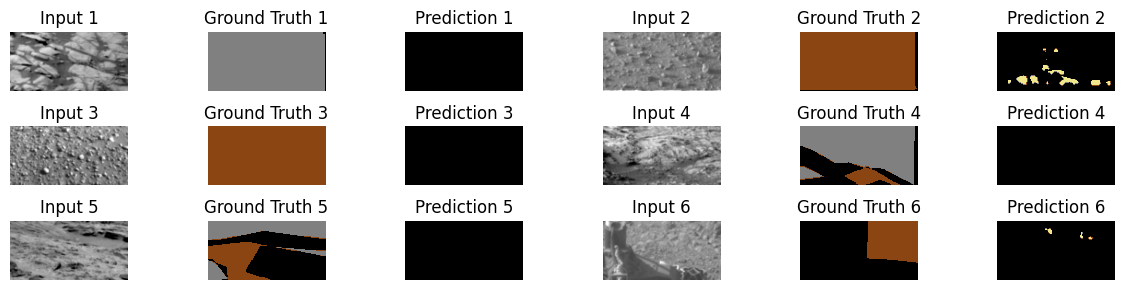

Updated weights : [3.55861213e+00 9.17280596e+03 3.58368227e+01 2.62150456e+00
 1.00000000e+06]
70/70 ━━━━━━━━━━━━━━━━━━━━ 87s 743ms/step - accuracy: 0.7397 - loss: 1273354.2500 - mean_iou: 0.4637 - val_accuracy: 0.3603 - val_loss: 2968142.0000 - val_mean_iou: 0.0938 - learning_rate: 0.0010
Epoch 2/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.7342 - loss: 1286591.3750 - mean_iou: 0.4523Updated weights : [ 2.7530561   2.20096768  2.79488451  2.24922297 73.05021883]
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 337ms/step - accuracy: 0.7342 - loss: 1286587.3750 - mean_iou: 0.4523 - val_accuracy: 0.5828 - val_loss: 1907975.2500 - val_mean_iou: 0.2789 - learning_rate: 0.0010
Epoch 3/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.7325 - loss: 1278121.0000 - mean_iou: 0.4530Updated weights : [ 3.01382331  2.64110348  2.44860025  2.33338881 48.543098  ]
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 336ms/step - accuracy: 0.7324 - loss: 1278174.1250 - mean_iou: 0.4530 - val_accuracy: 0.5561 - va

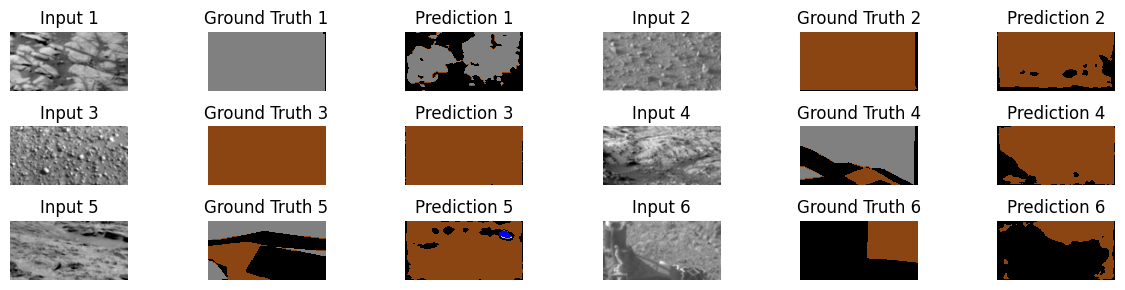

Updated weights : [ 2.98038255  2.1433704  13.24880908  2.15426186 14.75559622]
70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 350ms/step - accuracy: 0.7599 - loss: 1228394.7500 - mean_iou: 0.5028 - val_accuracy: 0.5491 - val_loss: 2021431.8750 - val_mean_iou: 0.2552 - learning_rate: 0.0010
Epoch 12/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.7668 - loss: 1225038.2500 - mean_iou: 0.5120Updated weights : [ 2.66963671  1.93562928  2.91549515  2.02638514 47.565305  ]
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 336ms/step - accuracy: 0.7668 - loss: 1225021.3750 - mean_iou: 0.5120 - val_accuracy: 0.6165 - val_loss: 1645327.7500 - val_mean_iou: 0.3050 - learning_rate: 0.0010
Epoch 13/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.7687 - loss: 1216941.6250 - mean_iou: 0.5109Updated weights : [3.04634756e+00 2.34666868e+00 4.42409317e+00 1.95958201e+00
 1.00000000e+06]
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 336ms/step - accuracy: 0.7687 - loss: 1216978.0000 - mean_iou: 0.5108 - val_accuracy: 0.5572 - 

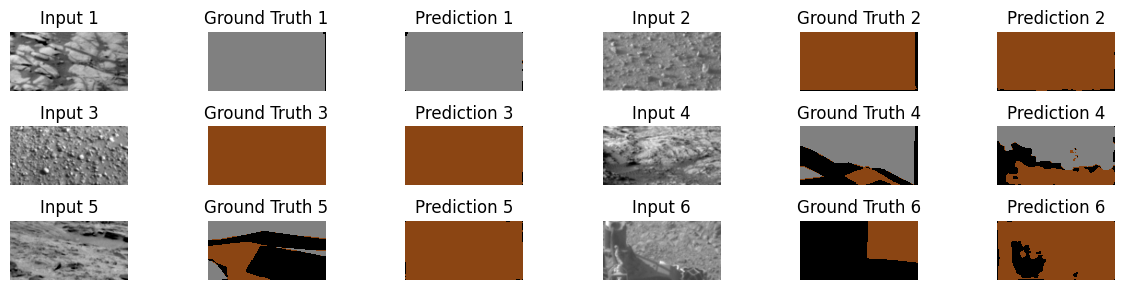

Updated weights : [ 3.10233923  1.60822133  2.51881055  1.59594644 71.57820953]
70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 351ms/step - accuracy: 0.8008 - loss: 1156589.0000 - mean_iou: 0.5714 - val_accuracy: 0.6825 - val_loss: 1529637.5000 - val_mean_iou: 0.3871 - learning_rate: 5.0000e-04
Epoch 22/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.8002 - loss: 1155518.2500 - mean_iou: 0.5685Updated weights : [ 2.71938036  1.70924838  4.07150755  1.61849298 10.54534334]
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 336ms/step - accuracy: 0.8003 - loss: 1155416.5000 - mean_iou: 0.5685 - val_accuracy: 0.6526 - val_loss: 1654083.3750 - val_mean_iou: 0.3480 - learning_rate: 5.0000e-04
Epoch 23/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.8041 - loss: 1143296.6250 - mean_iou: 0.5773Updated weights : [ 2.74618909  1.7455473   4.73122135  1.59101774 27.99921602]
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 336ms/step - accuracy: 0.8042 - loss: 1143291.8750 - mean_iou: 0.5773 - val_accuracy: 0.6452 - val_loss

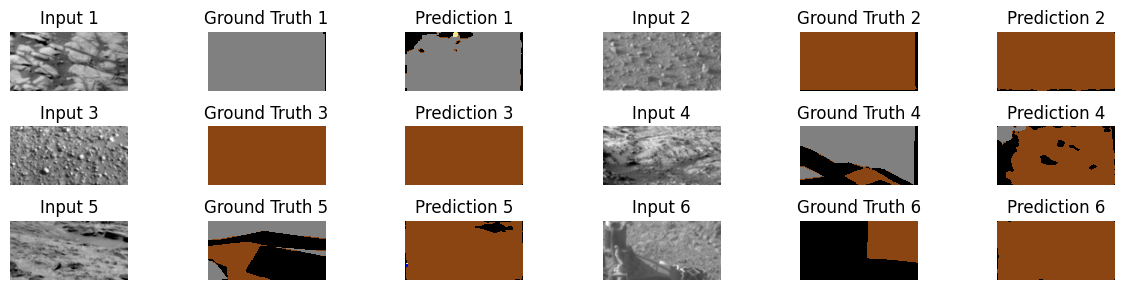

Updated weights : [3.05517617e+00 1.55522615e+00 2.69942540e+00 1.50295811e+00
 1.00000000e+06]
70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 350ms/step - accuracy: 0.8295 - loss: 1096282.5000 - mean_iou: 0.6143 - val_accuracy: 0.6910 - val_loss: 1536747.1250 - val_mean_iou: 0.3892 - learning_rate: 2.5000e-04
Epoch 32/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.8330 - loss: 1093431.1250 - mean_iou: 0.6211Updated weights : [ 3.02949727  1.49443947  2.69016994  1.54741383 95.70512537]
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 335ms/step - accuracy: 0.8330 - loss: 1093410.3750 - mean_iou: 0.6210 - val_accuracy: 0.6943 - val_loss: 1525374.2500 - val_mean_iou: 0.3939 - learning_rate: 2.5000e-04
Epoch 33/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.8329 - loss: 1088146.0000 - mean_iou: 0.6152Updated weights : [  2.9649243    1.48975019   2.21720918   1.57003103 191.24913106]
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 335ms/step - accuracy: 0.8329 - loss: 1088137.3750 - mean_iou: 0.6150 - val_accura

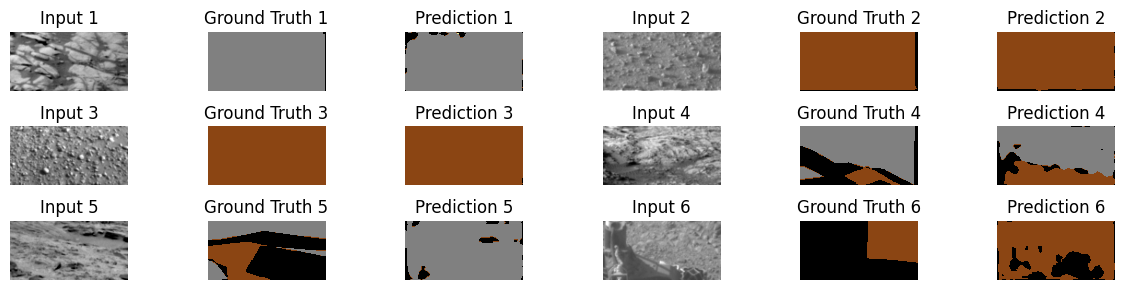

Updated weights : [ 2.92281954  1.4339149   1.86290404  1.59037088 35.48893657]
70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 349ms/step - accuracy: 0.8455 - loss: 1063613.1250 - mean_iou: 0.6376 - val_accuracy: 0.7233 - val_loss: 1468474.6250 - val_mean_iou: 0.4407 - learning_rate: 1.2500e-04
Epoch 42/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.8503 - loss: 1056355.3750 - mean_iou: 0.6417Updated weights : [ 3.08942992  1.50150168  2.08063611  1.57249429 34.26965888]
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 335ms/step - accuracy: 0.8503 - loss: 1056357.2500 - mean_iou: 0.6415 - val_accuracy: 0.7085 - val_loss: 1547734.5000 - val_mean_iou: 0.4236 - learning_rate: 6.2500e-05
Epoch 43/1000
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.8525 - loss: 1052584.6250 - mean_iou: 0.6382Updated weights : [ 3.14888945  1.50084018  2.03145768  1.57249334 24.4236459 ]
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 335ms/step - accuracy: 0.8525 - loss: 1052572.0000 - mean_iou: 0.6380 - val_accuracy: 0.7097 - val_loss

In [22]:
import tensorflow.keras.backend as K

mean_iou = tfk.metrics.MeanIoU(num_classes=5, ignore_class=0, sparse_y_pred=False, name='mean_iou')
iou_per_class = K.variable(value=[0, 0, 0, 0, 0]) # Init of the weights

adaptive_loss = AdaptiveCombinedLoss(
    iou_per_class=iou_per_class, lambda_1=0.3, lambda_2=0.7, epsilon=1e-6
)

# Compile the model
model.compile(
    loss=adaptive_loss,
    optimizer=tf.keras.optimizers.AdamW(LEARNING_RATE),
    metrics=["accuracy", mean_iou]
)
print("Model compiled!")


# Setup callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5, verbose=1
)

n = 6 # Number of images to visualize
viz_callback = VizCallback(val_dataset, frequency=10, n=n)
iou_callback = IoUUpdateCallback(iou_per_class=iou_per_class,val_data=val_dataset, num_classes=5)

# Train the model
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[lr_scheduler, early_stopping, viz_callback,iou_callback],
    verbose=1
).history

# Calculate and print the final validation accuracy
final_val_meanIoU = round(max(history['val_mean_iou'])* 100, 2)
print(f'Final validation Mean Intersection Over Union: {final_val_meanIoU}%')

## Other Losses Tests (Not convincing)

In [ ]:
class_frequencies = [5e6, 7e6, 6e6, 4.5e6, 0.5e6]
total_pixels = sum(class_frequencies)
class_weights = [total_pixels / (len(class_frequencies) * freq) for freq in class_frequencies]

# Normalize weights
class_weights = [w / sum(class_weights) for w in class_weights]
class_weights = [1,1,1,1,1]

def edge_loss(y_true, y_pred, smooth=1e-7):
    # Define Sobel kernels for edge detection
    sobel_x = tf.constant([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=tf.float32)
    sobel_y = tf.transpose(sobel_x)
    sobel_x = tf.reshape(sobel_x, [3, 3, 1, 1])
    sobel_y = tf.reshape(sobel_y, [3, 3, 1, 1])

    # Compute edges for ground truth (y_true)
    y_true_edges_x = tf.nn.conv2d(tf.cast(y_true, tf.float32), sobel_x, strides=1, padding='SAME')
    y_true_edges_y = tf.nn.conv2d(tf.cast(y_true, tf.float32), sobel_y, strides=1, padding='SAME')
    y_true_edges = tf.sqrt(tf.square(y_true_edges_x) + tf.square(y_true_edges_y))

    # Compute edges for predicted segmentation map (y_pred) for each class
    y_pred_edges = 0.0
    for i in range(y_pred.shape[-1]):
        y_pred_class = y_pred[..., i:i+1]  # Select the i-th class channel (batch_size, height, width, 1)
        
        # Apply Sobel filters to the i-th class channel
        y_pred_edges_x = tf.nn.conv2d(tf.cast(y_pred_class, tf.float32), sobel_x, strides=1, padding='SAME')
        y_pred_edges_y = tf.nn.conv2d(tf.cast(y_pred_class, tf.float32), sobel_y, strides=1, padding='SAME')
        y_pred_edges_class = tf.sqrt(tf.square(y_pred_edges_x) + tf.square(y_pred_edges_y))
        
        y_pred_edges += y_pred_edges_class  # Sum over all classes' edges

    # Compute the edge difference between the ground truth and predicted edges
    edge_diff = tf.abs(y_true_edges - y_pred_edges)

    # Compute final edge loss (mean over the batch)
    edge_loss_value = tf.reduce_mean(edge_diff)

    return edge_loss_value

def multi_scale_loss(y_true, y_pred, loss_fn,class_weights=class_weights, scales=[1, 0.5, 0.25]):
    total_loss = 0
    for scale in scales:
        if scale < 1:
            y_true_scaled = tf.image.resize(y_true, size=(int(y_true.shape[1] * scale), int(y_true.shape[2] * scale)))
            y_pred_scaled = tf.image.resize(y_pred, size=(int(y_pred.shape[1] * scale), int(y_pred.shape[2] * scale)))
        else:
            y_true_scaled, y_pred_scaled = y_true, y_pred
        if class_weights is not None :
            total_loss += loss_fn(y_true_scaled, y_pred_scaled,class_weights=class_weights)
        else :
            total_loss += loss_fn(y_true_scaled, y_pred_scaled)
        
    return total_loss / len(scales)

# Weighted Dice Loss
def weighted_dice_loss(y_true, y_pred, class_weights, smooth=1e-7):
    num_classes = len(class_weights)
    y_true_one_hot = K.one_hot(K.cast(y_true, 'int32'), num_classes=num_classes)  # One-hot encode
    y_pred_softmax = tf.nn.softmax(y_pred, axis=-1)  # Ensure predictions are softmax probabilities

    # Exclude the background class (assume it's class 0)
    y_true_one_hot = y_true_one_hot[..., 1:]  # Shape: (batch_size, height, width, num_classes-1)
    y_pred_softmax = y_pred_softmax[..., 1:]  # Shape: (batch_size, height, width, num_classes-1)

    # Compute weighted Dice for each class
    dice_scores = []
    for i, weight in enumerate(class_weights[1:]):  # Skip background class
        y_true_class = y_true_one_hot[..., i]  # Shape: (batch_size, height, width)
        y_pred_class = y_pred_softmax[..., i]  # Shape: (batch_size, height, width)
        
        # Ensure both tensors are 3D (remove unnecessary dimensions)
        y_true_class = tf.squeeze(y_true_class, axis=-1) if len(y_true_class.shape) > 3 else y_true_class
        y_pred_class = tf.squeeze(y_pred_class, axis=-1) if len(y_pred_class.shape) > 3 else y_pred_class

        # Compute intersection and union
        intersection = K.sum(y_true_class * y_pred_class, axis=[1, 2])  # Sum over spatial dimensions
        denominator = K.sum(y_true_class + y_pred_class, axis=[1, 2])  # Sum over spatial dimensions
        
        # Dice score for the class
        dice_class = (2. * intersection + smooth) / (denominator + smooth)
        
        # Weighted Dice score for the class
        weighted_dice_class = weight * dice_class
        dice_scores.append(weighted_dice_class)

    # Combine class-specific scores into a single loss
    weighted_dice = K.sum(K.stack(dice_scores, axis=0), axis=0)  # Sum of weighted scores
    mean_dice = K.mean(weighted_dice)  # Average across batch
    
    return 1 - mean_dice  # Final Dice loss (scalar)
    
# Weighted Sparse Categorical Crossentropy
def weighted_sparse_categorical_crossentropy(y_true, y_pred, class_weights):
    y_true = tf.cast(y_true, tf.int32)
    y_pred = tf.nn.softmax(y_pred, axis=-1)
    
    # Create tensor of class weights
    weights = tf.constant(class_weights, dtype=tf.float32)
    weights = tf.gather(weights, y_true)  # Get weights for each pixel in y_true
    
    # Sparse Categorical Crossentropy
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    
    # Multiply loss by weights and compute mean
    return tf.reduce_mean(loss * tf.squeeze(weights))

# Combined Loss
@keras.saving.register_keras_serializable()
def combined_loss(y_true, y_pred, d_weight=0.5, ce_weight=0.5,m_weight=0.0,e_weight=0.0):
    
    # Compute individual losses
    sparse_ce_loss = weighted_sparse_categorical_crossentropy(y_true, y_pred, class_weights)
    d_loss = weighted_dice_loss(y_true, y_pred,class_weights)
    multi_edge_loss = multi_scale_loss(y_true,y_pred,edge_loss,class_weights=None) 
    
    # Combine the losses
    return d_weight * d_loss + ce_weight * sparse_ce_loss + m_weight * multi_edge_loss

In [31]:
#timestep_str = datetime.now().strftime("%m%d_%H%M")
model_filename = f'CustomNet_{str(final_val_meanIoU)}_aug4_2.keras'

if (on_kaggle):
    model_filename = f"/kaggle/working/{model_filename}"

model.save(model_filename)
print(f"Model saved to {model_filename}")

Model saved to /kaggle/working/CustomNet_46.08_aug4_2.keras


## 📊 Prepare Your Submission

In our Kaggle competition, submissions are made as `csv` files. To create a proper `csv` file, you need to flatten your predictions and include an `id` column as the first column of your dataframe. To maintain consistency between your results and our solution, please avoid shuffling the test set. The code below demonstrates how to prepare the `csv` file from your model predictions.



Model loaded from /kaggle/working/CustomNet_46.08_aug4_2.keras
314/314 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step
Predictions shape: (10022, 64, 128)
Class counts: [21793001 27696987 18997200 13598566    14470]


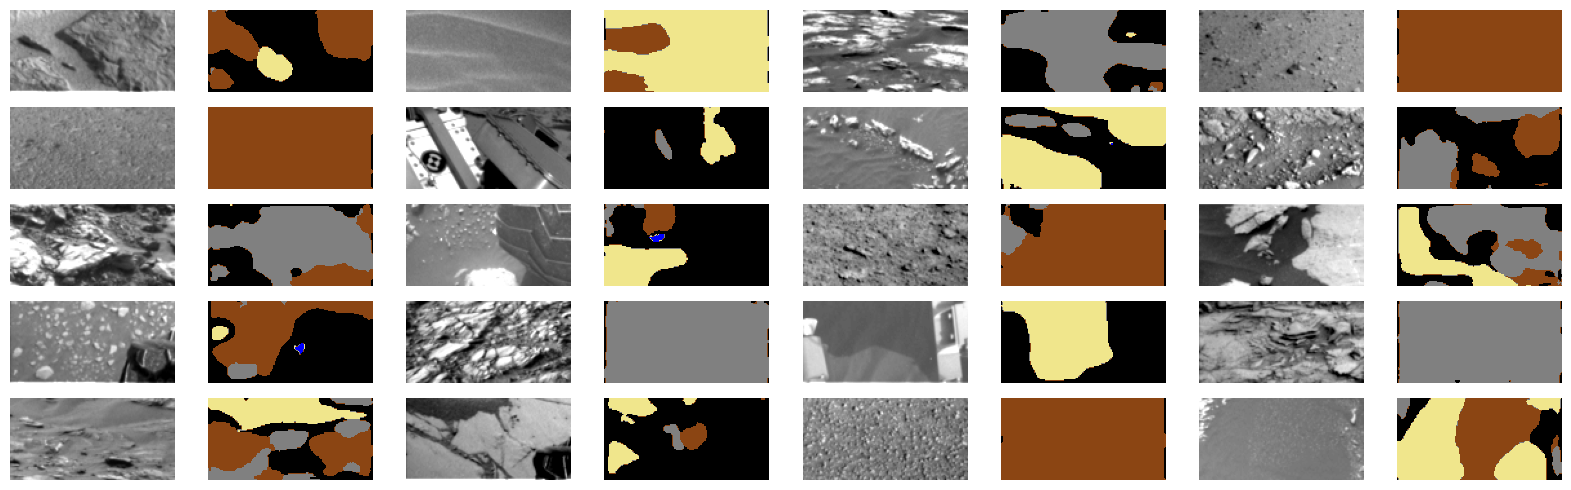

In [32]:
model_pred = tfk.models.load_model(model_filename)
print(f"Model loaded from {model_filename}")

X_test = apply_preprocessing(X_test_original) 
X_test = tf.cast(X_test, tf.float32)

preds = model_pred.predict(X_test)
preds = np.argmax(preds, axis=-1)
class_counts = np.bincount(preds.flatten(), minlength=5)

print(f"Predictions shape: {preds.shape}")
print(f"Class counts: {class_counts}")
plot_image_label(X_test, preds, 5, 4, 1)

In [33]:
def y_to_df(y) -> pd.DataFrame:
    n_samples = len(y)
    y_flat = y.reshape(n_samples, -1)
    df = pd.DataFrame(y_flat)
    df["id"] = np.arange(n_samples)
    cols = ["id"] + [col for col in df.columns if col != "id"]
    return df[cols]

submission_df = y_to_df(preds)
submission_filename = model_filename.replace(".keras", ".csv")
zip_filename = model_filename.replace(".keras", ".zip")
submission_df.to_csv(submission_filename, index=False)


with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    filename = submission_filename.replace("/kaggle/working/", "")
    zipf.write(submission_filename, arcname=filename)

os.remove(submission_filename)
print("Zip file with CSV created successfully!")

Zip file with CSV created successfully!
